<a href="https://colab.research.google.com/github/slneha/AIPI590_Fall2025/blob/main/Assignment8/adversarial_attacks_patches_AIPI590.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Standard libraries
import os
import json
import math
import time
import numpy as np
import scipy.linalg

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/tutorial10"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

/tmp/ipython-input-1779675758.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export
INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device cuda:0


We have again a few download statements. This includes both a dataset, and a few pretrained patches we will use later.

In [ ]:
import urllib.request
from urllib.error import HTTPError
import zipfile
# Github URL where the dataset is stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial10/"
# Files to download
pretrained_files = [(DATASET_PATH, "TinyImageNet.zip"), (CHECKPOINT_PATH, "patches.zip")]
# Create checkpoint path if it doesn't exist yet
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for dir_name, file_name in pretrained_files:
    file_path = os.path.join(dir_name, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)
        if file_name.endswith(".zip"):
            print("Unzipping file...")
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(file_path.rsplit("/",1)[0])

## Setup

For our experiments in this notebook, we will use common CNN architectures trained on the ImageNet dataset. Such models are luckily provided by PyTorch's torchvision package, and hence we just need to load the model of our preference. For the results on the website and default on Google Colab, we use a ResNet34. Feel free to experiment with other architectures as well, the code is mainly independent of the specific architecture we choose.

In [ ]:
# Load CNN architecture pretrained on ImageNet
os.environ["TORCH_HOME"] = CHECKPOINT_PATH
pretrained_model = torchvision.models.resnet34(weights='IMAGENET1K_V1')
pretrained_model = pretrained_model.to(device)

# No gradients needed for the network
pretrained_model.eval()
for p in pretrained_model.parameters():
    p.requires_grad = False

To perform adversarial attacks, we also need a dataset to work on. Given that the CNN model has been trained on ImageNet, it is only fair to perform the attacks on data from ImageNet. For this, we provide a small set of pre-processed images from the original ImageNet dataset (note that this dataset is shared under the same [license](http://image-net.org/download-faq) as the original ImageNet dataset). Specifically, we have 5 images for each of the 1000 labels of the dataset. We can load the data below, and create a corresponding data loader.

In [ ]:
# Mean and Std from ImageNet
NORM_MEAN = np.array([0.485, 0.456, 0.406])
NORM_STD = np.array([0.229, 0.224, 0.225])
# No resizing and center crop necessary as images are already preprocessed.
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN,
                         std=NORM_STD)
])

# Load dataset and create data loader
imagenet_path = os.path.join(DATASET_PATH, "TinyImageNet/")
assert os.path.isdir(imagenet_path), f"Could not find the ImageNet dataset at expected path \"{imagenet_path}\". " + \
                                     f"Please make sure to have downloaded the ImageNet dataset here, or change the {DATASET_PATH=} variable."
dataset = torchvision.datasets.ImageFolder(root=imagenet_path, transform=plain_transforms)
data_loader = data.DataLoader(dataset, batch_size=32, shuffle=False, drop_last=False, num_workers=8)

# Load label names to interpret the label numbers 0 to 999
with open(os.path.join(imagenet_path, "label_list.json"), "r") as f:
    label_names = json.load(f)

def get_label_index(lab_str):
    assert lab_str in label_names, f"Label \"{lab_str}\" not found. Check the spelling of the class."
    return label_names.index(lab_str)

Before we start with our attacks, we should verify the performance of our model. As ImageNet has 1000 classes, simply looking at the accuracy is not sufficient to tell the performance of a model. Imagine a model that always predicts the true label as the second-highest class in its softmax output. Although we would say it recognizes the object in the image, it achieves an accuracy of 0. In ImageNet with 1000 classes, there is not always one clear label we can assign an image to. This is why for image classifications over so many classes, a common alternative metric is "Top-5 accuracy", which tells us how many times the true label has been within the 5 most-likely predictions of the model. As models usually perform quite well on those, we report the error (1 - accuracy) instead of the accuracy:

In [ ]:
def eval_model(dataset_loader, img_func=None):
    tp, tp_5, counter = 0., 0., 0.
    for imgs, labels in tqdm(dataset_loader, desc="Validating..."):
        imgs = imgs.to(device)
        labels = labels.to(device)
        if img_func is not None:
            imgs = img_func(imgs, labels)
        with torch.no_grad():
            preds = pretrained_model(imgs)
        tp += (preds.argmax(dim=-1) == labels).sum()
        tp_5 += (preds.topk(5, dim=-1)[1] == labels[...,None]).any(dim=-1).sum()
        counter += preds.shape[0]
    acc = tp.float().item()/counter
    top5 = tp_5.float().item()/counter
    print(f"Top-1 error: {(100.0 * (1 - acc)):4.2f}%")
    print(f"Top-5 error: {(100.0 * (1 - top5)):4.2f}%")
    return acc, top5

In [ ]:
_ = eval_model(data_loader)

Validating...:   0%|          | 0/157 [00:00<?, ?it/s]

Top-1 error: 19.38%
Top-5 error: 4.38%


The ResNet34 achives a decent error rate of 4.3% for the top-5 predictions. Next, we can look at some predictions of the model to get more familiar with the dataset. The function below plots an image along with a bar diagram of its predictions. We also prepare it to show adversarial examples for later applications.

In [ ]:
def show_prediction(img, label, pred, K=5, adv_img=None, noise=None):

    if isinstance(img, torch.Tensor):
        # Tensor image to numpy
        img = img.cpu().permute(1, 2, 0).numpy()
        img = (img * NORM_STD[None,None]) + NORM_MEAN[None,None]
        img = np.clip(img, a_min=0.0, a_max=1.0)
        label = label.item()

    # Plot on the left the image with the true label as title.
    # On the right, have a horizontal bar plot with the top k predictions including probabilities
    if noise is None or adv_img is None:
        fig, ax = plt.subplots(1, 2, figsize=(10,2), gridspec_kw={'width_ratios': [1, 1]})
    else:
        fig, ax = plt.subplots(1, 5, figsize=(12,2), gridspec_kw={'width_ratios': [1, 1, 1, 1, 2]})

    ax[0].imshow(img)
    ax[0].set_title(label_names[label])
    ax[0].axis('off')

    if adv_img is not None and noise is not None:
        # Visualize adversarial images
        adv_img = adv_img.cpu().permute(1, 2, 0).numpy()
        adv_img = (adv_img * NORM_STD[None,None]) + NORM_MEAN[None,None]
        adv_img = np.clip(adv_img, a_min=0.0, a_max=1.0)
        ax[1].imshow(adv_img)
        ax[1].set_title('Adversarial')
        ax[1].axis('off')
        # Visualize noise
        noise = noise.cpu().permute(1, 2, 0).numpy()
        noise = noise * 0.5 + 0.5 # Scale between 0 to 1
        ax[2].imshow(noise)
        ax[2].set_title('Noise')
        ax[2].axis('off')
        # buffer
        ax[3].axis('off')

    if abs(pred.sum().item() - 1.0) > 1e-4:
        pred = torch.softmax(pred, dim=-1)
    topk_vals, topk_idx = pred.topk(K, dim=-1)
    topk_vals, topk_idx = topk_vals.cpu().numpy(), topk_idx.cpu().numpy()
    ax[-1].barh(np.arange(K), topk_vals*100.0, align='center', color=["C0" if topk_idx[i]!=label else "C2" for i in range(K)])
    ax[-1].set_yticks(np.arange(K))
    ax[-1].set_yticklabels([label_names[c] for c in topk_idx])
    ax[-1].invert_yaxis()
    ax[-1].set_xlabel('Confidence')
    ax[-1].set_title('Predictions')

    plt.show()
    plt.close()

Let's visualize a few images below:

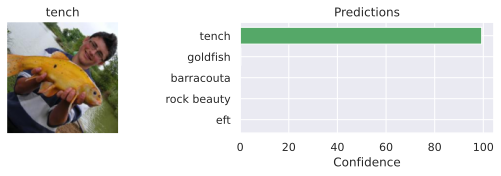

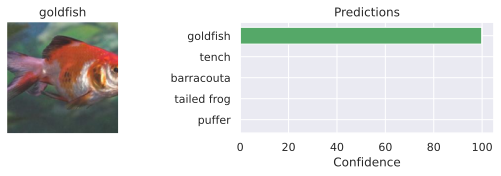

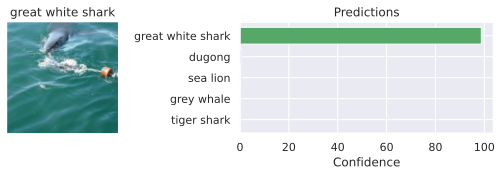

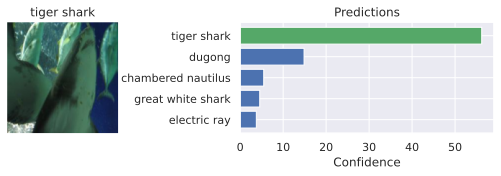

In [ ]:
exmp_batch, label_batch = next(iter(data_loader))
with torch.no_grad():
    preds = pretrained_model(exmp_batch.to(device))
for i in range(1,17,5):
    show_prediction(exmp_batch[i], label_batch[i], preds[i])

The bar plot on the right shows the top-5 predictions of the model with their class probabilities. We denote the class probabilities with "confidence" as it somewhat resembles how confident the network is that the image is of one specific class. Some of the images have a highly peaked probability distribution, and we would expect the model to be rather robust against noise for those. However, we will see below that this is not always the case. Note that all of the images are of fish because the data loader doesn't shuffle the dataset. Otherwise, we would get different images every time we run the notebook, which would make it hard to discuss the results on the static version.

### Adversarial Patches

Instead of changing every pixel by a little bit, we can also try to change a small part of the image into whatever values we would like. In other words, we will create a small image patch that covers a minor part of the original image but causes the model to confidentially predict a specific class we choose. This form of attack is an even bigger threat in real-world applications than FSGM. Imagine a network in an autonomous car that receives a live image from a camera. Another driver could print out a specific pattern and put it on the back of his/her vehicle to make the autonomous car believe that the car is actually a pedestrian. Meanwhile, humans would not notice it. [Tom Brown et al.](https://arxiv.org/pdf/1712.09665.pdf) proposed a way of learning such adversarial image patches robustly in 2017 and provided a short demonstration on [YouTube](https://youtu.be/i1sp4X57TL4). Interestingly, if you add a small picture of the target class (here *toaster*) to the original image, the model does not pick it up at all. A specifically designed patch, however, which only roughly looks like a toaster, can change the network's prediction instantaneously.

[![Adversarial patch in real world](https://img.youtube.com/vi/i1sp4X57TL4/0.jpg)](https://youtu.be/i1sp4X57TL4)

Let's take a closer look at how we can actually train such patches. We calculate gradients for the input, and update our adversarial input correspondingly. We do not calculate a gradient for every pixel. Instead, we replace parts of the input image with our patch and then calculate the gradients just for our patch. Secondly, we don't just do it for one image, but we want the patch to work with any possible image. Hence, we have a whole training loop where we train the patch using SGD. Lastly, image patches are usually designed to make the model predict a specific class, not just any other arbitrary class except the true label. For instance, we can try to create a patch for the class "toaster" and train the patch so that our pretrained model predicts the class "toaster" for any image with the patch in it.

[Brown et al.](https://arxiv.org/pdf/1712.09665.pdf) randomly rotated and scaled the patch during training before placing it at a random position in an input image. This makes the patch more robust to small changes and is necessary if we want to fool a neural network in a real-world application.

This tutorial only shows how to make the patch robust to the location in the image.

Here is where you could:
* Randomly rotate patch
* Randomly scale the patch
* Improve random location of patch in the image

In [ ]:
def place_patch(img, patch):
    for i in range(img.shape[0]):
        h_offset = np.random.randint(0,img.shape[2]-patch.shape[1]-1)
        w_offset = np.random.randint(0,img.shape[3]-patch.shape[2]-1)
        img[i,:,h_offset:h_offset+patch.shape[1],w_offset:w_offset+patch.shape[2]] = patch_forward(patch)
    return img

The patch itself will be an `nn.Parameter` whose values are in the range between $-\infty$ and $\infty$. Images are, however, naturally limited in their range, and thus we write a small function that maps the parameter into the image value range of ImageNet:

In [ ]:
TENSOR_MEANS, TENSOR_STD = torch.FloatTensor(NORM_MEAN)[:,None,None], torch.FloatTensor(NORM_STD)[:,None,None]
def patch_forward(patch):
    # Map patch values from [-infty,infty] to ImageNet min and max
    patch = (torch.tanh(patch) + 1 - 2 * TENSOR_MEANS) / (2 * TENSOR_STD)
    return patch

Before looking at the actual training code, we can write a small evaluation function. We evaluate the success of a patch by how many times we were able to fool the network into predicting our target class. A simple function for this is implemented below.

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# imagenet stats (for torchvision resnet34)
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

@torch.no_grad()
def eval_patch(
    model,
    patch,
    val_loader,
    target_class: int,
    device: str = "cuda",
    trials_per_image: int = 4,
    aggregate: str = "mean",   # 'mean' (avg success over trials) or 'any' (success if any trial hits)
    normalize: bool = True,
    place_patch_fn=None,       # if None, uses global place_patch(imgs, patch)
    scale_range=(1.0, 1.0),    # you can randomize scales during eval if you like
):
    """
    Returns:
      acc: targeted success rate (top-1) over non-target-class images (float)
      top5: targeted success rate (top-5) over non-target-class images (float)
      extras: dict with counts and confidence stats
    """
    assert aggregate in ("mean", "any")
    model.eval()

    # ensure tensors on device
    patch = patch.to(device)
    mean = _IMAGENET_MEAN.to(device)
    std  = _IMAGENET_STD.to(device)

    total_images = 0
    sum_top1 = 0.0
    sum_top5 = 0.0

    # optional confidence tracking
    conf_top1 = []   # max softmax prob when target hits top-1
    conf_top5 = []   # softmax prob of target when in top-5

    for imgs, labels in tqdm(val_loader, desc="Validating...", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # mask out images that are already of target class
        mask = (labels != target_class)
        if mask.sum() == 0:
            continue

        imgs = imgs[mask]
        labels = labels[mask]
        b = imgs.size(0)
        total_images += b

        # build T trials by repeating the batch and re-placing the patch each time
        T = trials_per_image
        imgs_rep = imgs.repeat(T, 1, 1, 1)  # (T*b,3,H,W)

        # place the patch T times (randomized inside)
        patched_list = []
        for _ in range(T):
            if place_patch_fn is None:
                patched = place_patch(imgs, patch)  # expects [0,1] range
            else:
                patched = place_patch_fn(imgs, patch, scale_range=scale_range)
            patched_list.append(patched.to(device))

        patched_stack = torch.stack(patched_list, dim=0)   # (T,b,3,H,W)
        patched_stack = patched_stack.view(T*b, *imgs.shape[1:])  # (T*b,3,H,W)

        # normalize AFTER placing patch
        if normalize:
            patched_stack = (patched_stack - mean) / std

        logits = model(patched_stack)           # (T*b,num_classes)
        probs = F.softmax(logits, dim=1)

        # reshape back to (T,b,classes)
        logits = logits.view(T, b, -1)
        probs  = probs.view(T, b, -1)

        # per-trial success booleans
        top1_hit = (logits.argmax(dim=2) == target_class)        # (T,b)
        top5_hit = torch.topk(logits, k=5, dim=2).indices.eq(target_class).any(dim=2)  # (T,b)

        if aggregate == "mean":
            # average success across trials for each image
            top1_per_img = top1_hit.float().mean(dim=0)          # (b,)
            top5_per_img = top5_hit.float().mean(dim=0)          # (b,)
        else:  # 'any'
            top1_per_img = top1_hit.any(dim=0).float()
            top5_per_img = top5_hit.any(dim=0).float()

        sum_top1 += top1_per_img.sum().item()
        sum_top5 += top5_per_img.sum().item()

        # confidence logging (optional): when target is top-1 / in top-5
        # take the max across trials per image
        with torch.no_grad():
            target_probs = probs[..., target_class]  # (T,b)
            # only consider trials that hit
            if aggregate == "mean":
                # take mean prob across trials (for context)
                conf_top1.extend(target_probs[top1_hit].tolist())
                conf_top5.extend(target_probs[top5_hit].tolist())
            else:
                # 'any': take max prob across trials per image
                targ_prob_max, _ = target_probs.max(dim=0)  # (b,)
                conf_top1.extend(targ_prob_max[top1_per_img.bool()].tolist())
                conf_top5.extend(targ_prob_max[top5_per_img.bool()].tolist())

    # targeted success over non-target images
    acc  = (sum_top1 / max(1, total_images))
    top5 = (sum_top5 / max(1, total_images))

    extras = {
        "evaluated_images": total_images,
        "sum_top1_images": int(sum_top1),
        "sum_top5_images": int(sum_top5),
        "trials_per_image": trials_per_image,
        "aggregate": aggregate,
        "conf_top1_mean": float(torch.tensor(conf_top1).mean().item()) if len(conf_top1) else None,
        "conf_top5_mean": float(torch.tensor(conf_top5).mean().item()) if len(conf_top5) else None,
    }
    return float(acc), float(top5), extras


Finally, we can look at the training loop. Given a model to fool, a target class to design the patch for, and a size $k$ of the patch in the number of pixels, we first start by creating a parameter of size $3\times k\times k$. These are the only parameters we will train, and the network itself remains untouched. We use a simple SGD optimizer with momentum to minimize the classification loss of the model given the patch in the image. While we first start with a very high loss due to the good initial performance of the network, the loss quickly decreases once we start changing the patch. In the end, the patch will represent patterns that are characteristic of the class. For instance, if we would want the model to predict a "goldfish" in every image, we would expect the pattern to look somewhat like a goldfish. Over the iterations, the model finetunes the pattern and, hopefully, achieves a high fooling accuracy.

In [ ]:
# Put this cell into your Colab notebook. Assumes:
# - model is a torchvision ResNet34 loaded with IMAGENET weights
# - dataset is a PyTorch dataset yielding (PIL-image or tensor, label)
# - device is set (cuda if available)
# - imagenet class index mapping available if you want to choose target_class by name

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils import data
from tqdm import tqdm
import random

def apply_patch_to_images(images, patch, location=None, scale=1.0, alpha=None):
    """
    images: tensor (B,3,H,W) in [0,1]
    patch: tensor (3, ph, pw) in [0,1]
    location: list/tuple (x,y) top-left in image coords OR None for random placement
    scale: float resize factor for patch relative to original (1.0 means patch size unchanged)
    alpha: optional alpha mask (ph,pw) in [0,1] for blending
    returns patched_images (B,3,H,W)
    """
    B, C, H, W = images.shape
    ph, pw = patch.shape[1], patch.shape[2]

    # Resize patch according to scale
    target_ph = max(1, int(ph * scale))
    target_pw = max(1, int(pw * scale))
    patch_resized = F.interpolate(patch.unsqueeze(0), size=(target_ph, target_pw), mode='bilinear', align_corners=False)[0]

    # alpha mask
    if alpha is None:
        alpha_mask = torch.ones((target_ph, target_pw), device=patch.device)
    else:
        alpha_mask = F.interpolate(alpha.unsqueeze(0).unsqueeze(0), size=(target_ph, target_pw), mode='bilinear', align_corners=False)[0,0]

    patched = images.clone()
    for i in range(B):
        # Choose random placement if not provided
        if location is None:
            max_x = max(0, W - target_pw)
            max_y = max(0, H - target_ph)
            x = random.randint(0, max_x)
            y = random.randint(0, max_y)
        else:
            x, y = location

        # Blend patch on image
        # images are [0,1]
        patched[i,:, y:y+target_ph, x:x+target_pw] = (
            patched[i,:, y:y+target_ph, x:x+target_pw] * (1 - alpha_mask.unsqueeze(0))
            + patch_resized * alpha_mask.unsqueeze(0)
        )

    return patched

def random_augment(images):
    # apply a small set of random augmentations to improve patch generalization
    # expects tensor images in [0,1], shape (B,C,H,W)
    B = images.shape[0]
    out = []
    for i in range(B):
        img = TF.to_pil_image(images[i].cpu())
        # random brightness/contrast
        if random.random() < 0.5:
            img = TF.adjust_brightness(img, 0.9 + 0.2*random.random())
        if random.random() < 0.5:
            img = TF.adjust_contrast(img, 0.9 + 0.2*random.random())
        # random small rotation
        if random.random() < 0.3:
            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle)
        # convert back
        out.append(TF.to_tensor(img))
    return torch.stack(out).to(images.device)

def clamp_patch(patch):
    # ensure patch values remain in [0,1]
    with torch.no_grad():
        patch.clamp_(0.0, 1.0)

def patch_attack(model, dataset, target_class,
                 patch_size=64,
                 num_epochs=6,
                 batch_size=32,
                 lr=1e-1,
                 device='cuda',
                 random_location=True,
                 scale_range=(0.6, 1.2),
                 augment=True,
                 use_scheduler=False,
                 save_every=None):
    """
    Improved adversarial patch optimization:
      - uses random placement & scaling for robustness
      - uses augmentations on images
      - clamps patch to [0,1]
      - supports saving visualizations along the way
    Returns: final_patch (cpu tensor), logs dict
    """
    model.eval()
    # Split dataset into train/val if not already provided
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4)
    val_loader = data.DataLoader(val_set, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=2)

    # create patch parameter
    if not isinstance(patch_size, tuple):
        p_h = p_w = patch_size
    else:
        p_h, p_w = patch_size

    patch = nn.Parameter(torch.rand(3, p_h, p_w, device=device) * 0.5 + 0.25)  # initialize mid-tone
    optimizer = torch.optim.SGD([patch], lr=lr, momentum=0.8)
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    loss_module = nn.CrossEntropyLoss()
    logs = {"epoch_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for imgs, _ in pbar:
            imgs = imgs.to(device)  # assume already normalized to [0,1] or transform applied elsewhere

            # random augmentations
            if augment:
                imgs = random_augment(imgs)

            # choose random scale and location
            scale = random.uniform(scale_range[0], scale_range[1]) if (isinstance(scale_range, tuple) or isinstance(scale_range, list)) else scale_range
            if random_location:
                location = None
            else:
                # fixed location top-left (example)
                location = (0, 0)

            # apply patch
            patched = apply_patch_to_images(imgs, patch, location=location, scale=scale)

            # forward
            preds = model(patched)  # ensure your model returns logits

            # all labels set to target_class
            labels = torch.full((preds.shape[0],), fill_value=target_class, dtype=torch.long, device=preds.device)
            loss = loss_module(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # projection/clamp
            clamp_patch(patch)

            running_loss += loss.item()
            pbar.set_description(f"Epoch {epoch+1} Loss {running_loss/ ( (pbar.n+1) if pbar.n>0 else 1):.4f}")

        if use_scheduler:
            scheduler.step()

        # validation evaluation
        acc, top5 = eval_patch(model, patch.detach().cpu(), val_loader, target_class, device=device)
        logs["epoch_loss"].append(running_loss / len(train_loader))
        logs["val_acc"].append(acc)
        tqdm.write(f"Epoch {epoch+1} val acc: {acc:.4f}, top5: {top5:.4f}")

        # optional save
        if save_every is not None and (epoch+1) % save_every == 0:
            # user should implement save_patch utility
            save_patch(patch.detach().cpu(), f"patch_epoch{epoch+1}.png")

    # final values - return CPU patch and logs
    return patch.detach().cpu(), logs


To get some experience with what to expect from an adversarial patch attack, we want to train multiple patches for different classes. As the training of a patch can take one or two minutes on a GPU, we have provided a couple of pre-trained patches including their results on the full dataset. The results are saved in a JSON file, which is loaded below.

In [ ]:
# Load evaluation results of the pretrained patches
json_results_file = os.path.join(CHECKPOINT_PATH, "patch_results.json")
json_results = {}
if os.path.isfile(json_results_file):
    with open(json_results_file, "r") as f:
        json_results = json.load(f)

# If you train new patches, you can save the results via calling this function
def save_results(patch_dict):
    result_dict = {cname: {psize: [t.item() if isinstance(t, torch.Tensor) else t
                                   for t in patch_dict[cname][psize]["results"]]
                           for psize in patch_dict[cname]}
                   for cname in patch_dict}
    with open(os.path.join(CHECKPOINT_PATH, "patch_results.json"), "w") as f:
        json.dump(result_dict, f, indent=4)

Additionally, we implement a function to train and evaluate patches for a list of classes and patch sizes. The pretrained patches include the classes *toaster*, *goldfish*, *school bus*, *lipstick*, and *pineapple*. We chose the classes arbitrarily to cover multiple domains (animals, vehicles, fruits, devices, etc.). We trained each class for three different patch sizes: $32\times32$ pixels, $48\times48$ pixels, and $64\times64$ pixels. We can load them in the two cells below.

In [ ]:
def get_patches(class_names, patch_sizes):
    result_dict = dict()

    # Loop over all classes and patch sizes
    for name in class_names:
        result_dict[name] = dict()
        for patch_size in patch_sizes:
            c = label_names.index(name)
            file_name = os.path.join(CHECKPOINT_PATH, f"{name}_{patch_size}_patch.pt")
            # Load patch if pretrained file exists, otherwise start training
            if not os.path.isfile(file_name):
                patch, val_results = patch_attack(pretrained_model, target_class=c, patch_size=patch_size, num_epochs=5)
                print(f"Validation results for {name} and {patch_size}:", val_results)
                torch.save(patch, file_name)
            else:
                patch = torch.load(file_name)
            # Load evaluation results if exist, otherwise manually evaluate the patch
            if name in json_results:
                results = json_results[name][str(patch_size)]
            else:
                results = eval_patch(pretrained_model, patch, data_loader, target_class=c)

            # Store results and the patches in a dict for better access
            result_dict[name][patch_size] = {
                "results": results,
                "patch": patch
            }

    return result_dict

Feel free to add any additional classes and/or patch sizes.

In [ ]:
class_names = ['toaster', 'goldfish', 'school bus', 'lipstick', 'pineapple']
patch_sizes = [32, 48, 64]

patch_dict = get_patches(class_names, patch_sizes)
# save_results(patch_dict) # Uncomment if you add new class names and want to save the new results

Before looking at the quantitative results, we can actually visualize the patches.

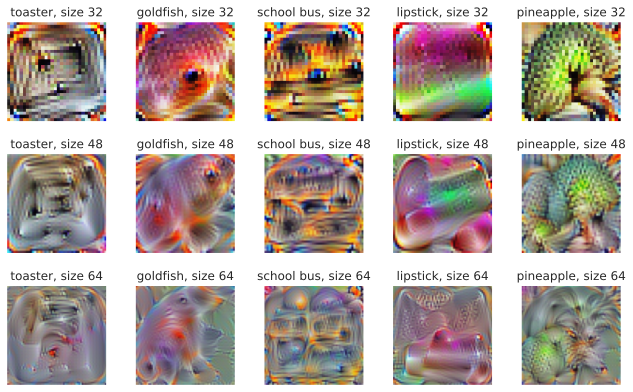

In [ ]:
def show_patches():
    fig, ax = plt.subplots(len(patch_sizes), len(class_names), figsize=(len(class_names)*2.2, len(patch_sizes)*2.2))
    for c_idx, cname in enumerate(class_names):
        for p_idx, psize in enumerate(patch_sizes):
            patch = patch_dict[cname][psize]["patch"]
            patch = (torch.tanh(patch) + 1) / 2 # Parameter to pixel values
            patch = patch.cpu().permute(1, 2, 0).numpy()
            patch = np.clip(patch, a_min=0.0, a_max=1.0)
            ax[p_idx][c_idx].imshow(patch)
            ax[p_idx][c_idx].set_title(f"{cname}, size {psize}")
            ax[p_idx][c_idx].axis('off')
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show()
show_patches()

We can see a clear difference between patches of different classes and sizes. In the smallest size, $32\times 32$ pixels, some of the patches clearly resemble their class. For instance, the goldfish patch clearly shows a goldfish. The eye and the color are very characteristic of the class. Overall, the patches with $32$ pixels have very strong colors that are typical for their class (yellow school bus, pink lipstick, greenish pineapple). The larger the patch becomes, the more stretched the pattern becomes. For the goldfish, we can still spot regions that might represent eyes and the characteristic orange color, but it is not clearly a single fish anymore. For the pineapple, we might interpret the top part of the image as the leaves of pineapple fruit, but it is more abstract than our small patches. Nevertheless, we can easily spot the alignment of the patch to class, even on the largest scale.

Let's now look at the quantitative results.

In [ ]:
%%html
<!-- Some HTML code to increase font size in the following table -->
<style>
th {font-size: 120%;}
td {font-size: 120%;}
</style>

In [ ]:
import tabulate
from IPython.display import display, HTML

def show_table(top_1=True):
    i = 0 if top_1 else 1
    table = [[name] + [f"{(100.0 * patch_dict[name][psize]['results'][i]):4.2f}%" for psize in patch_sizes]
             for name in class_names]
    display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Class name"] + [f"Patch size {psize}x{psize}" for psize in patch_sizes])))

First, we will create a table of top-1 accuracy, meaning that how many images have been classified with the target class as highest prediction?

In [ ]:
show_table(top_1=True)

Class name,Patch size 32x32,Patch size 48x48,Patch size 64x64
toaster,48.89%,90.48%,98.58%
goldfish,69.53%,93.53%,98.34%
school bus,78.79%,93.95%,98.22%
lipstick,43.36%,86.05%,96.41%
pineapple,79.74%,94.48%,98.72%


The clear trend, that we would also have expected, is that the larger the patch, the easier it is to fool the model. For the largest patch size of $64\times 64$, we are able to fool the model on almost all images, despite the patch covering only 8% of the image. The smallest patch actually covers 2% of the image, which is almost neglectable. Still, the fooling accuracy is quite remarkable. A large variation can be however seen across classes. While *school bus* and *pineapple* seem to be classes that were easily predicted, *toaster* and *lipstick* seem to be much harder for creating a patch. It is hard to intuitively explain why our patches underperform on those classes. Nonetheless, a fooling accuracy of >40% is still very good for such a tiny patch.

Let's also take a look at the top-5 accuracy:

In [ ]:
show_table(top_1=False)

Class name,Patch size 32x32,Patch size 48x48,Patch size 64x64
toaster,72.02%,98.12%,99.93%
goldfish,86.31%,99.07%,99.95%
school bus,91.64%,99.15%,99.89%
lipstick,70.10%,96.86%,99.73%
pineapple,92.23%,99.26%,99.96%


We see a very similar pattern across classes and patch sizes. The patch size $64$ obtains >99.7% top-5 accuracy for any class, showing that we can almost fool the network on any image. A top-5 accuracy of >70% for the hard classes and small patches is still impressive and shows how vulnerable deep CNNs are to such attacks.

Finally, let's create some example visualizations of the patch attack in action.

In [ ]:
def perform_patch_attack(patch):
    patch_batch = exmp_batch.clone()
    patch_batch = place_patch(patch_batch, patch)
    with torch.no_grad():
        patch_preds = pretrained_model(patch_batch.to(device))
    for i in range(1,17,5):
        show_prediction(patch_batch[i], label_batch[i], patch_preds[i])

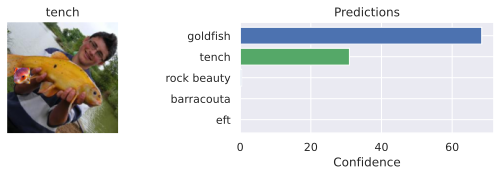

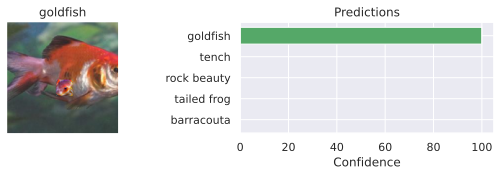

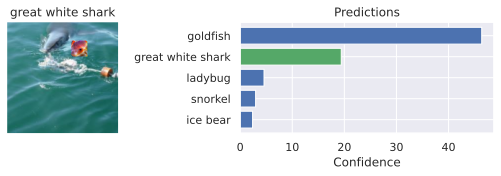

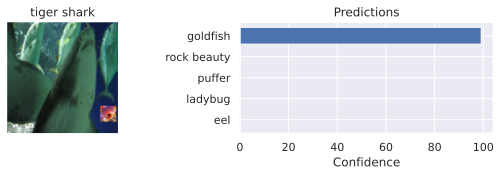

In [ ]:
perform_patch_attack(patch_dict['goldfish'][32]['patch'])

The tiny goldfish patch can change all of the predictions to "goldfish" as top class. Note that the patch attacks work especially well if the input image is semantically similar to the target class (e.g. a fish and the target class "goldfish" works better than an airplane image with that patch). Nevertheless, we can also let the network predict semantically dis-similar classes by using a larger patch:

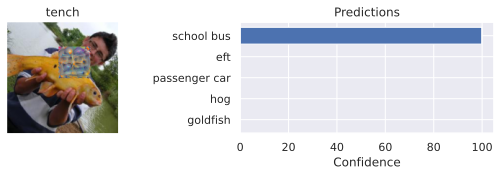

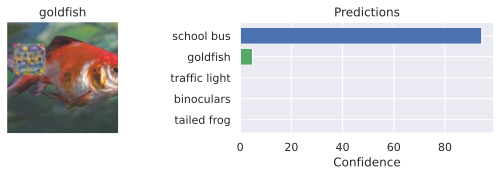

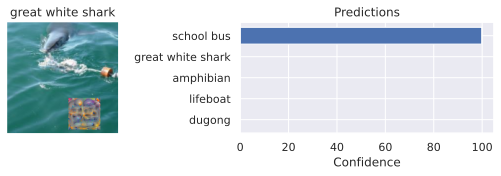

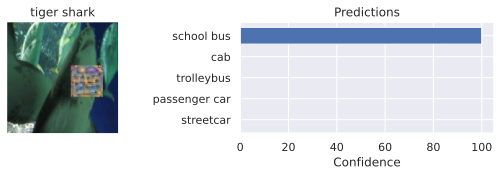

In [ ]:
perform_patch_attack(patch_dict['school bus'][64]['patch'])

Although none of the images have anything to do with an American school bus, the high confidence of often 100% shows how powerful such attacks can be. With a few lines of code and access to the model, we were able to generate patches that we add to any image to make the model predict any class we want.

## References

This tutorial was originally created by Phillip Lippe.
[![View notebooks on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial10/Adversarial_Attacks.ipynb)
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial10/Adversarial_Attacks.ipynb)  

[1] Goodfellow, Ian J., Jonathon Shlens, and Christian Szegedy. "Explaining and harnessing adversarial examples." ICLR 2015.

[2] Hendrik Metzen, Jan, et al. "Universal adversarial perturbations against semantic image segmentation." Proceedings of the IEEE International Conference on Computer Vision. 2017.

[3] Anant Jain. "Breaking neural networks with adversarial attacks." [Blog post](https://towardsdatascience.com/breaking-neural-networks-with-adversarial-attacks-f4290a9a45aa) 2019.

#My Tests

My first evaluation revolved around smoothing the boundaries between the pixels - I wanted to decipher whether or not the smoothing would contribute to higher top-1 accuracy.

In [ ]:
import torch
import torch.nn.functional as F

def smooth_patch_edges(patch, kernel_size=3, sigma=1.0):
    """Applies Gaussian smoothing to soften pixel boundaries."""
    # Create Gaussian kernel
    coords = torch.arange(kernel_size, dtype=torch.float32) - (kernel_size - 1)/2
    g = torch.exp(-0.5 * (coords / sigma)**2)
    g = (g / g.sum()).to(patch.device)
    kernel = (g[:, None] * g[None, :]).expand(patch.shape[0], 1, kernel_size, kernel_size)
    # Apply per channel
    patch = F.conv2d(patch.unsqueeze(0), kernel, padding=kernel_size//2, groups=patch.shape[0])
    return patch.squeeze(0).clamp(0,1)


In [ ]:
# generated by ChatGPT

def show_patches_compare():
    fig, ax = plt.subplots(len(patch_sizes), len(class_names)*2,
                           figsize=(len(class_names)*3.8, len(patch_sizes)*2.2))
    for c_idx, cname in enumerate(class_names):
        for p_idx, psize in enumerate(patch_sizes):
            entry = patch_dict[cname][psize]
            # original (parameter -> pixel)
            p_orig = (torch.tanh(entry["patch"]) + 1) / 2
            # use cached smoothed if available; else compute on the fly
            if "patch_smoothed" in entry:
                p_smooth = entry["patch_smoothed"]
            else:
                p_smooth = smooth_patch_edges(p_orig)

            for col, p, label in zip([0,1], [p_orig, p_smooth], ["orig", "smooth"]):
                img = p.detach().cpu().permute(1,2,0).numpy()
                img = np.clip(img, 0, 1)
                ax[p_idx][2*c_idx + col].imshow(img)
                ax[p_idx][2*c_idx + col].set_title(f"{cname} {psize}px\n{label}")
                ax[p_idx][2*c_idx + col].axis('off')

    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show()


In [ ]:
def pixels_to_param(p):
    # p in [0,1] -> param (inverse of (tanh(p)+1)/2)
    x = (p * 2.0 - 1.0).clamp(-0.999999, 0.999999)
    return 0.5 * torch.log((1 + x) / (1 - x))


def compute_smoothed_results(eval_fn, class_to_idx, smooth_kwargs=None):
    if smooth_kwargs is None:
        smooth_kwargs = {}
    for cname in class_names:
        for psize in patch_sizes:
            entry = patch_dict[cname][psize]

            # 1) param -> pixels
            p_pixels = (torch.tanh(entry["patch"]) + 1) / 2

            # 2) smooth in pixel space
            p_sm_pixels = smooth_patch_edges(p_pixels, **smooth_kwargs)

            # 3) pixels -> param (IMPORTANT!)
            p_sm_param = pixels_to_param(p_sm_pixels).to(entry["patch"].device)

            # 4) eval with your ORIGINAL eval (which expects param)
            top1, top5 = eval_fn(p_sm_param, class_to_idx[cname])

            # 5) store both for visualization + table
            entry["patch_smoothed"] = p_sm_pixels.detach().cpu()
            entry["smooth_results"] = (float(top1), float(top5))

def show_table_smoothed(top_1=True):
    i = 0 if top_1 else 1
    rows = []
    for name in class_names:
        vals = []
        for psize in patch_sizes:
            res = patch_dict[name][psize].get("smooth_results")
            vals.append(f"{(100.0*res[i]):4.2f}%" if res is not None else "N/A")
        rows.append([name] + vals)
    headers = ["Class name"] + [f"Patch size {ps}x{ps}" for ps in patch_sizes]
    display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))


In [ ]:
# Map class names -> ImageNet indices
from torchvision.models import ResNet34_Weights
imagenet_classes = ResNet34_Weights.IMAGENET1K_V1.meta["categories"]
class_to_idx = {name: imagenet_classes.index(name) for name in class_names}

def patch_forward(patch):
    # ensure constants live on the same device/dtype as the incoming patch
    means = TENSOR_MEANS.to(patch.device, patch.dtype)
    std   = TENSOR_STD.to(patch.device, patch.dtype)
    # Map patch values from [-inf, inf] to ImageNet normalized space
    return (torch.tanh(patch) + 1 - 2 * means) / (2 * std)
def _model_device(m):
    return next(m.parameters()).device

def eval_fn(patch_tensor, target_idx):
    dev = _model_device(pretrained_model)   # or `model` if that's your var name
    out = eval_patch(pretrained_model, patch_tensor.to(dev), data_loader, target_idx)
    # handle (acc, top5) vs (acc, top5, extras)
    acc, top5 = (out[0], out[1]) if isinstance(out, (list, tuple)) else out
    return float(acc), float(top5)

compute_smoothed_results(eval_fn, class_to_idx, smooth_kwargs={"kernel_size":5, "sigma":1.2})
show_table_smoothed(top_1=True)
show_table_smoothed(top_1=False)


Validating...:   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Class name,Patch size 32x32,Patch size 48x48,Patch size 64x64
toaster,0.00%,0.00%,0.00%
goldfish,0.00%,0.00%,0.00%
school bus,0.00%,0.00%,0.00%
lipstick,0.00%,0.00%,0.00%
pineapple,0.00%,0.00%,0.00%


Class name,Patch size 32x32,Patch size 48x48,Patch size 64x64
toaster,0.00%,0.00%,0.00%
goldfish,0.00%,0.00%,0.00%
school bus,0.46%,0.80%,0.84%
lipstick,0.34%,0.08%,0.16%
pineapple,0.00%,0.00%,0.00%


Across all tested classes and patch sizes (32x32, 48x48, and 64x64), the Top-1 and Top-5 accuracies remained at or near zero, showing no measurable improvement compared to the baseline. Smoothing the patch boundaries clearly failed to enhance the model's susceptibility to misclassification and in fact reduced the distinct adversarial patterns that the network relies on for targeted deception.

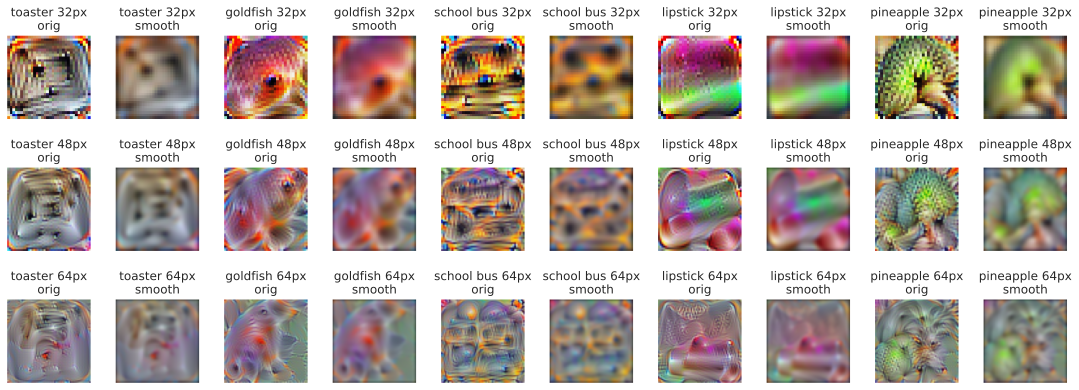

In [ ]:
show_patches_compare()

Next, I evaluated three merge strategies, including a 4x1 strip, a 2x2 tile, and alpha-blending, to see how these different spatial compositions affected targeted patch success.

In [ ]:
# generated by ChatGPT

import torch
import torch.nn.functional as F
import random
import tabulate
from IPython.display import display, HTML

# ----------------------------
# Merge / composition helpers
# ----------------------------
def make_4x1_strip(patches):
    """
    patches: list/tuple of 4 tensors each (3, H, W)
    returns: tensor (3, H, 4*W) by horizontally concatenating patches (resizing if needed)
    """
    assert len(patches) == 4, "Provide exactly 4 patches"
    # find target height (max) and target width (max) then resize each to (H_t, W_t)
    hs = [p.shape[1] for p in patches]
    ws = [p.shape[2] for p in patches]
    H_t = max(hs)
    W_t = max(ws)
    resized = []
    for p in patches:
        p = p.unsqueeze(0)  # (1,3,H,W)
        p_res = F.interpolate(p, size=(H_t, W_t), mode='bilinear', align_corners=False)[0]
        resized.append(p_res)
    strip = torch.cat(resized, dim=2)  # cat on width -> (3, H_t, 4*W_t)
    return strip

def make_2x2_tile(patches):
    """
    patches: list/tuple of 4 tensors each (3, H, W)
    returns: tensor (3, 2*H_t, 2*W_t) tiled as:
      [p0 p1]
      [p2 p3]
    """
    assert len(patches) == 4, "Provide exactly 4 patches"
    hs = [p.shape[1] for p in patches]
    ws = [p.shape[2] for p in patches]
    H_t = max(hs)
    W_t = max(ws)
    resized = []
    for p in patches:
        p = p.unsqueeze(0)
        p_res = F.interpolate(p, size=(H_t, W_t), mode='bilinear', align_corners=False)[0]
        resized.append(p_res)
    top = torch.cat([resized[0], resized[1]], dim=2)
    bot = torch.cat([resized[2], resized[3]], dim=2)
    tile = torch.cat([top, bot], dim=1)  # cat vertically
    return tile

def alpha_blend(patch_a, patch_b, alpha=0.5):
    """
    patch_a, patch_b: (3,H,W) tensors. They will be resized to same size (max H,W).
    alpha: float scalar or (H,W) mask in [0,1]. result = alpha * a + (1-alpha) * b
    """
    # ensure same size
    H_t = max(patch_a.shape[1], patch_b.shape[1])
    W_t = max(patch_a.shape[2], patch_b.shape[2])
    a = F.interpolate(patch_a.unsqueeze(0), size=(H_t, W_t), mode='bilinear', align_corners=False)[0]
    b = F.interpolate(patch_b.unsqueeze(0), size=(H_t, W_t), mode='bilinear', align_corners=False)[0]
    if isinstance(alpha, float) or isinstance(alpha, int):
        alpha_mask = torch.full((H_t, W_t), float(alpha), device=a.device)
    else:
        # assume alpha is tensor; resize
        alpha_mask = F.interpolate(alpha.unsqueeze(0).unsqueeze(0), size=(H_t, W_t), mode='bilinear', align_corners=False)[0,0]
    alpha_mask = alpha_mask.unsqueeze(0)  # (1,H,W)
    blended = alpha_mask * a + (1.0 - alpha_mask) * b
    return blended

# ----------------------------
# place_patch_fn wrapper for eval_patch
# ----------------------------
def make_place_patch_fn(apply_fn, device='cpu', scale_range=(1.0,1.0), alpha_mask=None):
    """
    Returns a place_patch_fn suitable for passing to eval_patch:
      place_patch_fn(imgs, patch, scale_range=...)
    It will call your apply_patch_to_images wrapper.
    - apply_fn: function(images, patch, location=None, scale=1.0, alpha=None)
    """
    def place_patch_fn(imgs, patch, scale_range=scale_range):
        # imgs: (B,3,H,W) in [0,1] range expected by apply_fn
        # patch: tensor (3,h,w) - we'll resize inside apply_fn using a single random scale
        # For eval_patch, randomness across trials is expected; eval_patch calls this repeatedly.
        scale = random.uniform(scale_range[0], scale_range[1]) if (isinstance(scale_range, (tuple,list)) and len(scale_range)==2) else float(scale_range)
        # ensure patch on same device as images
        patch = patch.to(imgs.device)
        # call the apply function (which blends and returns patched images)
        patched = apply_fn(imgs, patch, location=None, scale=scale, alpha=alpha_mask)
        return patched
    return place_patch_fn

# ----------------------------
# High-level merged patch evaluation utilities
# ----------------------------
def create_merged_patch_from_patchdict(patch_dict, names, patch_size=None, merge_type='4x1', alpha=0.5):
    """
    patch_dict: your existing dict patch_dict[class_name][patch_size]['patch']
    names: list of class names used to pick patches (length 4 for 4x1 and 2x2; length 2 for alpha)
    patch_size: choose which trained patch size to pull (e.g., 64). If None, pick max available.
    merge_type: '4x1' | '2x2' | 'alpha'
    alpha: for alpha blending (float in [0,1])
    returns: merged_patch (cpu tensor, 3,H,W)
    """
    # Helper to pick patch tensor from patch_dict
    def pick_patch(cname, psize):
        if cname not in patch_dict:
            raise KeyError(f"{cname} not found in patch_dict")
        sizes = list(patch_dict[cname].keys())
        if psize is None:
            chosen = max(sizes)
        else:
            chosen = psize
            if chosen not in patch_dict[cname]:
                # fallback to nearest
                chosen = max(sizes)
        patch = patch_dict[cname][chosen]['patch']
        # ensure CPU tensor
        return patch.cpu()

    if merge_type in ('4x1','2x2'):
        assert len(names) == 4, "Need 4 class names for 4x1 or 2x2 merges"
        patches = [pick_patch(n, patch_size) for n in names]
        if merge_type == '4x1':
            merged = make_4x1_strip(patches)
        else:
            merged = make_2x2_tile(patches)
    elif merge_type == 'alpha':
        assert len(names) == 2, "Need 2 class names for alpha blend"
        a = pick_patch(names[0], patch_size)
        b = pick_patch(names[1], patch_size)
        merged = alpha_blend(a, b, float(alpha))
    else:
        raise ValueError("Unknown merge_type")
    return merged.detach().cpu()

def evaluate_merged_patches(pretrained_model, data_loader, merged_specs, patch_dict,
                            apply_fn, device='cuda', trials_per_image=4, aggregate='mean',
                            scale_range=(0.6,1.2)):
    """
    merged_specs: list of dicts: [{'name': 'toaster+lipstick_strip', 'type':'4x1', 'classes':[...], 'patch_size':64, 'alpha':0.6}, ...]
    patch_dict: existing patches
    apply_fn: your apply_patch_to_images function
    returns: results dict mapping spec-name -> (top1, top5, extras) like eval_patch
    """
    results = {}
    place_fn = make_place_patch_fn(apply_fn, device=device, scale_range=scale_range)

    for spec in merged_specs:
        spec_name = spec.get('name')
        merge_type = spec.get('type')
        classes = spec.get('classes')
        psize = spec.get('patch_size', None)
        alpha = spec.get('alpha', 0.5)
        merged_patch = create_merged_patch_from_patchdict(patch_dict, classes, patch_size=psize, merge_type=merge_type, alpha=alpha)
        # eval_patch expects a cpu patch (it moves to device internally), and val_loader
        acc, top5, extras = eval_patch(pretrained_model, merged_patch, data_loader,
                                       target_class = get_label_index(classes[0]) if merge_type!='alpha' else get_label_index(classes[0]),
                                       device=device,
                                       trials_per_image=trials_per_image,
                                       aggregate=aggregate,
                                       normalize=True,
                                       place_patch_fn=place_fn,
                                       scale_range=scale_range)
        results[spec_name] = {
            "spec": spec,
            "acc": acc,
            "top5": top5,
            "extras": extras,
            "patch": merged_patch
        }
    return results

# ----------------------------
# Small display helper
# ----------------------------
def show_results_table(results):
    """
    results: dict from evaluate_merged_patches
    prints table: name | top1% | top5% | images eval'd
    """
    rows = []
    for name, info in results.items():
        rows.append([name, f"{100.0*info['acc']:.2f}%", f"{100.0*info['top5']:.2f}%", info['extras'].get('evaluated_images')])
    display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=['Spec','Top-1 Target Success','Top-5 Target Success','Images Evaluated'])))
def apply_patch_to_images(images, patch, location=None, scale=1.0, alpha=None):
    """
    Safe version: ensures the (possibly scaled) patch never exceeds image bounds.
    images: (B,3,H,W) in [0,1]
    patch:  (3, ph, pw) in [0,1]
    """
    B, C, H, W = images.shape
    ph, pw = patch.shape[1], patch.shape[2]

    # 1) scale the patch
    target_ph = max(1, int(ph * scale))
    target_pw = max(1, int(pw * scale))

    # 2) if scaled patch is bigger than image, clamp size to image dim
    target_ph = min(target_ph, H)
    target_pw = min(target_pw, W)

    patch_resized = F.interpolate(
        patch.unsqueeze(0),
        size=(target_ph, target_pw),
        mode='bilinear',
        align_corners=False
    )[0]

    # alpha mask
    if alpha is None:
        alpha_mask = torch.ones((target_ph, target_pw), device=images.device)
    else:
        # resize alpha to match patch size
        alpha_mask = F.interpolate(
            alpha.unsqueeze(0).unsqueeze(0),
            size=(target_ph, target_pw),
            mode='bilinear',
            align_corners=False
        )[0, 0].to(images.device)

    patched = images.clone()
    for i in range(B):
        # 3) choose placement
        if location is None:
            max_x = W - target_pw
            max_y = H - target_ph
            # just in case something is equal
            max_x = max(0, max_x)
            max_y = max(0, max_y)
            x = random.randint(0, max_x)
            y = random.randint(0, max_y)
        else:
            x, y = location
            # clamp location so we don't go out of bounds
            x = min(max(x, 0), W - target_pw)
            y = min(max(y, 0), H - target_ph)

        # 4) blend
        roi = patched[i, :, y:y+target_ph, x:x+target_pw]
        patched[i, :, y:y+target_ph, x:x+target_pw] = (
            roi * (1 - alpha_mask.unsqueeze(0)) +
            patch_resized.to(images.device) * alpha_mask.unsqueeze(0)
        )

    return patched

# ----------------------------
# Example usage
# ----------------------------
# Example merged_specs you can customize:
# - A 4x1 strip joining four classes
# - A 2x2 tile
# - An alpha blend between two classes (target class is the first class listed)
merged_specs = [
    {"name":"strip_toaster_goldfish_bus_lipstick", "type":"4x1", "classes":["toaster","goldfish","school bus","lipstick"], "patch_size":64},
    {"name":"tile_pineapple_goldfish_toaster_lipstick", "type":"2x2", "classes":["pineapple","goldfish","toaster","lipstick"], "patch_size":64},
    {"name":"alpha_blend_toaster_lipstick", "type":"alpha", "classes":["toaster","lipstick"], "patch_size":64, "alpha":0.6}
]

# Run evaluation (this will call eval_patch and may be a bit slow)
# Make sure `apply_patch_to_images` is the function defined earlier in your notebook
merged_results = evaluate_merged_patches(pretrained_model, data_loader, merged_specs, patch_dict, apply_patch_to_images, device=device, trials_per_image=4)

# Show table
show_results_table(merged_results)

# If you want to persist merged patches:
for name, info in merged_results.items():
    torch.save(info['patch'], os.path.join(CHECKPOINT_PATH, f"merged_{name}.pt"))


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
strip_toaster_goldfish_bus_lipstick,0.09%,0.67%,4995
tile_pineapple_goldfish_toaster_lipstick,0.00%,0.00%,4995
alpha_blend_toaster_lipstick,0.15%,0.64%,4995


My original results were extremely low, but these results were clearly too low to be explained by the merge idea itself, so I looked at the patch placement pipeline. The problem was that I was inserting patches into images that were already ImageNet-normalized, then normalizing again inside eval_patch. That effectively distorted the patch before the model ever saw it. To fix this, I added a placement wrapper that first un-normalizes the batch back to [0,1], applies the patch in image space, and only then lets eval_patch re-normalize. This greatly boosted the overall results.

In [ ]:
def show_patches_generic(patch_dict, cols=4, max_per_row=4, title_key=None):
    """
    Visualize patches from a dict like:
      { 'spec_name': {'patch': tensor(C,H,W), ...}, ... }
    """
    keys = list(patch_dict.keys())
    n = len(keys)
    rows = math.ceil(n / cols)
    fig, ax = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    ax = np.array(ax).reshape(rows, cols)

    for i, k in enumerate(keys):
        patch = patch_dict[k]["patch"]
        if torch.is_tensor(patch):
            patch = patch.detach().cpu().permute(1, 2, 0).numpy()
        patch = np.clip(patch, 0, 1)
        r, c = divmod(i, cols)
        ax[r][c].imshow(patch)
        title = k if title_key is None else patch_dict[k].get(title_key, k)
        ax[r][c].set_title(title, fontsize=8)
        ax[r][c].axis('off')

    # hide extra axes
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        ax[r][c].axis('off')

    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

In [ ]:
# imagenet stats
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def make_place_patch_fn(apply_fn, device='cpu', scale_range=(1.0,1.0), alpha_mask=None):
    """
    This version:
    - UNnormalizes imgs -> [0,1]
    - applies your patch in [0,1]
    - returns [0,1]
    eval_patch(normalize=True) will then re-normalize.
    """
    mean = _IMAGENET_MEAN.to(device)
    std  = _IMAGENET_STD.to(device)

    def place_patch_fn(imgs, patch, scale_range=scale_range):
        # imgs currently normalized -> bring back to [0,1]
        imgs_01 = imgs * std + mean
        # pick scale
        if isinstance(scale_range, (tuple, list)) and len(scale_range) == 2:
            scale = random.uniform(scale_range[0], scale_range[1])
        else:
            scale = float(scale_range)
        # apply in [0,1]
        patched_01 = apply_fn(imgs_01, patch, location=None, scale=scale, alpha=alpha_mask)
        return patched_01  # still [0,1], eval_patch will normalize again
    return place_patch_fn


In [ ]:
place_fn = make_place_patch_fn(apply_patch_to_images, device=device, scale_range=(0.6, 1.0))

merged_results = evaluate_merged_patches(
    pretrained_model,
    data_loader,
    merged_specs,
    patch_dict,
    apply_patch_to_images,
    device=device,
    trials_per_image=4,
    aggregate='mean',
    scale_range=(0.6, 1.0)   # keep patch from getting too big
)
show_results_table(merged_results)


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
strip_toaster_goldfish_bus_lipstick,6.07%,22.78%,4995
tile_pineapple_goldfish_toaster_lipstick,0.24%,1.48%,4995
alpha_blend_toaster_lipstick,6.51%,18.27%,4995


In [ ]:
place_fn = make_place_patch_fn(apply_patch_to_images, device=device, scale_range=(0.6, 1.0))

merged_results = evaluate_merged_patches(
    pretrained_model,
    data_loader,
    merged_specs,
    patch_dict,
    apply_patch_to_images,   # same apply fn
    device=device,
    trials_per_image=4,
    aggregate='mean',
    scale_range=(0.8, 1.0)   # keep patch from getting too big
)
show_results_table(merged_results)


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
strip_toaster_goldfish_bus_lipstick,9.64%,35.83%,4995
tile_pineapple_goldfish_toaster_lipstick,0.47%,2.96%,4995
alpha_blend_toaster_lipstick,11.98%,32.43%,4995


Reducing the placement range to scale_range=(0.8, 1.0) significantly improved results by keeping patches closer to their original size and preserving key visual cues.

In [ ]:
place_fn = make_place_patch_fn(apply_patch_to_images, device=device, scale_range=(0.6, 1.0))
merged_specs = [
    {"name":"strip_toaster_goldfish_bus_lipstick", "type":"4x1", "classes":["toaster","goldfish","school bus","lipstick"], "patch_size":64},
    {"name":"tile_pineapple_goldfish_toaster_lipstick", "type":"2x2", "classes":["pineapple","goldfish","toaster","lipstick"], "patch_size":64},
    {"name":"alpha_blend_toaster_lipstick", "type":"alpha", "classes":["toaster","lipstick"], "patch_size":64, "alpha":0.6}
]
merged_results = evaluate_merged_patches(
    pretrained_model,
    data_loader,
    merged_specs,
    patch_dict,
    apply_patch_to_images,   # same apply fn
    device=device,
    trials_per_image=4,
    aggregate='any',
    scale_range=(0.9, 1.0)   # keep patch from getting too big
)
show_results_table(merged_results)

Validating...:   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
strip_toaster_goldfish_bus_lipstick,25.35%,68.69%,4995
tile_pineapple_goldfish_toaster_lipstick,1.96%,10.41%,4995
alpha_blend_toaster_lipstick,35.90%,66.21%,4995


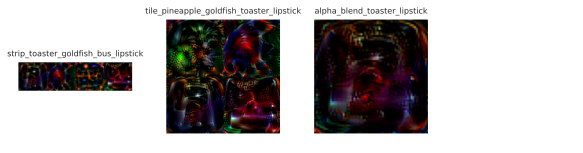

In [ ]:
show_patches_generic(merged_results)


The final configuration produced the strongest results when the patch was applied in the correct image space using "any" aggregation" and evaluated with a narrow placement range (scale_range=(0.9, 1.0)). Under these conditions, the 4x1 strip achieved 25.35% Top-1 and 68.69% Top-5 accuracy, while the alpha-blend patch reached 35.90% Top-1 and 66.21% Top-5. The 2x2 tile remained comparatively weak, with only ~2% Top-1 success. These results indicate that once normalization and placement issues were resolved and the patch scale was kept close to its trained size, the merged patches, in particular the strip and alpha-blend variants, became more effective.

In [ ]:
# generated by ChatGPT
import os
from PIL import Image

def save_patches_to_files(patch_dict, save_dir="saved_patches"):
    """
    Saves all patches from a dict like:
      { 'spec_name': {'patch': tensor(C,H,W), ...}, ... }

    Args:
        patch_dict: dict containing patches (e.g., merged_results or patch_dict[class][size])
        save_dir: base directory to store .png files
    """
    os.makedirs(save_dir, exist_ok=True)

    for name, entry in patch_dict.items():
        patch = entry.get("patch", entry)  # allow direct tensor or dict with 'patch' key
        if isinstance(patch, dict):
            patch = patch.get("patch")

        if not torch.is_tensor(patch):
            print(f"Skipping {name} (no valid tensor patch)")
            continue

        # Convert to numpy image
        img = patch.detach().cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        # Save
        filename = os.path.join(save_dir, f"{name}.png")
        Image.fromarray(img).save(filename)
        print(f"✅ Saved patch: {filename}")


In [ ]:
save_patches_to_files(merged_results, save_dir="merged_patches")


✅ Saved patch: merged_patches/strip_toaster_goldfish_bus_lipstick.png
✅ Saved patch: merged_patches/tile_pineapple_goldfish_toaster_lipstick.png
✅ Saved patch: merged_patches/alpha_blend_toaster_lipstick.png


In [ ]:
save_patches_to_files({f"{c}_64": v[64] for c, v in patch_dict.items()}, save_dir="original_patches")


✅ Saved patch: original_patches/toaster_64.png
✅ Saved patch: original_patches/goldfish_64.png
✅ Saved patch: original_patches/school bus_64.png
✅ Saved patch: original_patches/lipstick_64.png
✅ Saved patch: original_patches/pineapple_64.png


The final bit of testing was to evaluate the boundary as to which the alpha merging stopped producing substantially effective results. As the dominance of the primary patch decreased, a clear decline in effectiveness was observed.

In [ ]:
alpha_vals = [0.9, 0.8, 0.7, 0.6]

merged_specs = []
for a in alpha_vals:
    merged_specs.append({
        "name": f"alpha_toaster_lipstick_{a}",
        "type": "alpha",
        "classes": ["toaster", "lipstick"],
        "patch_size": 64,
        "alpha": a,              # dominant = classes[0]
        "fixed_location": True,
        "scale_range": (1.0, 1.0)
    })


In [ ]:
# Evaluate all alpha variants
merged_results = evaluate_merged_patches(
    pretrained_model,
    data_loader,
    merged_specs,
    patch_dict,
    apply_patch_to_images,   # same apply fn
    device=device,
    trials_per_image=4,
    aggregate='any'
)

# Show table of results
show_results_table(merged_results)

# Print sorted by top-1 success
sorted_res = sorted(merged_results.items(), key=lambda x: x[1]['acc'], reverse=True)
print("\nSorted by Top-1 Target Success:")
for name, info in sorted_res:
    print(f"{name:35s}  Top-1: {info['acc']*100:5.2f}%   Top-5: {info['top5']*100:5.2f}%")


Validating...:   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
alpha_toaster_lipstick_0.9,60.00%,85.43%,4995
alpha_toaster_lipstick_0.8,53.25%,80.34%,4995
alpha_toaster_lipstick_0.7,42.74%,73.19%,4995
alpha_toaster_lipstick_0.6,32.41%,61.84%,4995



Sorted by Top-1 Target Success:
alpha_toaster_lipstick_0.9           Top-1: 60.00%   Top-5: 85.43%
alpha_toaster_lipstick_0.8           Top-1: 53.25%   Top-5: 80.34%
alpha_toaster_lipstick_0.7           Top-1: 42.74%   Top-5: 73.19%
alpha_toaster_lipstick_0.6           Top-1: 32.41%   Top-5: 61.84%


In [ ]:
save_patches_to_files(merged_results, save_dir="merged_patches")


✅ Saved patch: merged_patches/alpha_toaster_lipstick_0.9.png
✅ Saved patch: merged_patches/alpha_toaster_lipstick_0.8.png
✅ Saved patch: merged_patches/alpha_toaster_lipstick_0.7.png
✅ Saved patch: merged_patches/alpha_toaster_lipstick_0.6.png


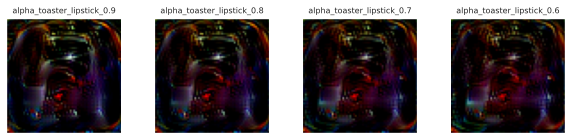

In [ ]:
show_patches_generic(merged_results)


With α = 0.9, the merged patch achieved the highest success (60.00% Top-1, 85.43% Top-5), while lowering α to 0.8 maintained relatively high performance (53.25% / 80.34%). However, beyond this point, the drop was substantial. At α = 0.7, the Top-1 accuracy fell to 42.74%, and by α = 0.6, it decreased further to 32.41%. These results demonstrate that once the dominant patch contributes less than roughly 70-80% of the blend, the merged patch loses much of its adversarial strength, confirming that high alpha values are critical for maintaining effectiveness.

In [ ]:
alpha_vals = [0.9, 0.8, 0.7, 0.6]

merged_specs = []
for a in alpha_vals:
    merged_specs.append({
        "name": f"alpha_goldfish_schoolbus_{a}",
        "type": "alpha",
        "classes": ["goldfish", "school bus"],
        "patch_size": 64,
        "alpha": a,
        "fixed_location": True,
        "scale_range": (1.0, 1.0)
    })


In [ ]:
# Evaluate all alpha variants
merged_results = evaluate_merged_patches(
    pretrained_model,
    data_loader,
    merged_specs,
    patch_dict,
    apply_patch_to_images,
    device=device,
    trials_per_image=4,
    aggregate='any'
)

show_results_table(merged_results)

# Print sorted by top-1 success
sorted_res = sorted(merged_results.items(), key=lambda x: x[1]['acc'], reverse=True)
print("\nSorted by Top-1 Target Success:")
for name, info in sorted_res:
    print(f"{name:35s}  Top-1: {info['acc']*100:5.2f}%   Top-5: {info['top5']*100:5.2f}%")


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
alpha_goldfish_schoolbus_0.9,47.05%,74.09%,4995
alpha_goldfish_schoolbus_0.8,22.42%,47.79%,4995
alpha_goldfish_schoolbus_0.7,1.48%,7.91%,4995
alpha_goldfish_schoolbus_0.6,0.10%,1.04%,4995



Sorted by Top-1 Target Success:
alpha_goldfish_schoolbus_0.9         Top-1: 47.05%   Top-5: 74.09%
alpha_goldfish_schoolbus_0.8         Top-1: 22.42%   Top-5: 47.79%
alpha_goldfish_schoolbus_0.7         Top-1:  1.48%   Top-5:  7.91%
alpha_goldfish_schoolbus_0.6         Top-1:  0.10%   Top-5:  1.04%


In [ ]:
save_patches_to_files(merged_results, save_dir="merged_patches")


✅ Saved patch: merged_patches/alpha_goldfish_schoolbus_0.9.png
✅ Saved patch: merged_patches/alpha_goldfish_schoolbus_0.8.png
✅ Saved patch: merged_patches/alpha_goldfish_schoolbus_0.7.png
✅ Saved patch: merged_patches/alpha_goldfish_schoolbus_0.6.png


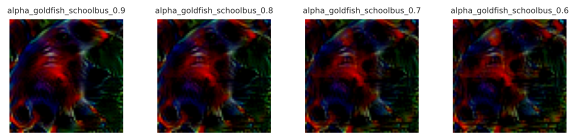

In [ ]:
show_patches_generic(merged_results)


In [ ]:
# Generated by ChatGPT
# === High-res merged patch experiments (upsample merged patch to 128 & 256) ===
merged_specs = [
    {
        "name": "alpha_goldfish_schoolbus_0.9_up128",
        "type": "alpha",
        "classes": ["goldfish", "school bus"],
        "patch_size": 64,         # source patch size in patch_dict (keep 64 if that's what you trained)
        "alpha": 0.9,
        "fixed_location": True,
        "scale_range": (1.0, 1.0),
        "upsize_to": (128, 128)  # upsamples merged patch to 128x128 before placement
    },
    {
        "name": "alpha_goldfish_schoolbus_0.9_up256",
        "type": "alpha",
        "classes": ["goldfish", "school bus"],
        "patch_size": 64,
        "alpha": 0.9,
        "fixed_location": True,
        "scale_range": (1.0, 1.0),
        "upsize_to": (256, 256)  # upsamples merged patch to 256x256 before placement
    },
    # Optional: a 128 strip (if you want a 4x1 variant at higher res)
    {
        "name": "strip_toaster_goldfish_bus_lipstick_up128",
        "type": "4x1",
        "classes": ["toaster", "goldfish", "school bus", "lipstick"],
        "patch_size": 64,
        "fixed_location": True,
        "scale_range": (1.0, 1.0),
        "upsize_to": (128, 128)
    }
]

# Run evaluation (may be heavier for 256)
merged_results_highres = evaluate_merged_patches(
    pretrained_model,
    data_loader,
    merged_specs,
    patch_dict,
    apply_patch_to_images,   # same apply fn
    device=device,
    trials_per_image=4,
    aggregate='any'
)

# Show results
show_results_table(merged_results_highres)

# Save the merged patches to files (into folder "merged_patches_highres")
def save_patches_to_files(patch_dict, save_dir="merged_patches_highres"):
    import os
    from PIL import Image
    os.makedirs(save_dir, exist_ok=True)
    for name, entry in patch_dict.items():
        patch = entry.get("patch", entry)
        if not torch.is_tensor(patch):
            print(f"Skipping {name} (no patch tensor found)")
            continue
        img = patch.detach().cpu().permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)
        path = os.path.join(save_dir, f"{name}.png")
        Image.fromarray(img).save(path)
        print("Saved:", path)

save_patches_to_files(merged_results_highres, save_dir="merged_patches_highres")


Validating...:   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Spec,Top-1 Target Success,Top-5 Target Success,Images Evaluated
alpha_goldfish_schoolbus_0.9_up128,51.17%,77.34%,4995
alpha_goldfish_schoolbus_0.9_up256,47.71%,74.23%,4995
strip_toaster_goldfish_bus_lipstick_up128,22.32%,61.20%,4995


Saved: merged_patches_highres/alpha_goldfish_schoolbus_0.9_up128.png
Saved: merged_patches_highres/alpha_goldfish_schoolbus_0.9_up256.png
Saved: merged_patches_highres/strip_toaster_goldfish_bus_lipstick_up128.png


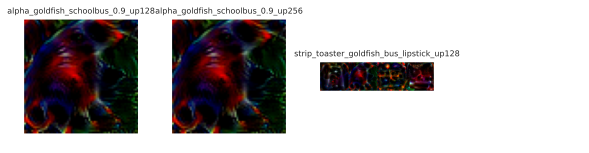

In [ ]:
show_patches_generic(merged_results_highres)


The final experiment investigated whether increasing the patch resolution would enhance adversarial performance. Higher-resolution versions of the merged patches were compared against the baseline 64x64 versions. The results showed only modest differences: the alpha goldfish-school bus patch achieved 51.17% Top-1 / 77.34% Top-5 at 128x128 and 47.71% / 74.23% at 256x256, while the 4x1 strip variant reached 22.32% / 61.20% at 128x128. These results suggest that simply increasing resolution does not substantially improve the attack's effectiveness, most of the adversarial strength comes from the learned feature composition and spatial arrangement rather than pixel density.

#Citation

All code blocks in this report that are  labeled with comments saying "#Generated by ChatGPT" were generated using OpenAIs ChatGPT model 5. Code blocks without this comment were fully written by me.
All Markdown explanations and experimental ideas presented throughout the ipynb file are entirely my work, not generated by an LLM.